# 3.7.softmax回归的简洁实现

在 [<span style="color: #ffbf00; font-weight: bold;"> 3.3节 </span>](./03.03_linear_regression_concise.ipynb)中，我们发现通过深度学习框架的高级API能够使实现 softmax 线性回归变得更加容易。同样，通过深度学习框架的高级API也能更方便地实现softmax回归模型。本节如在 [<span style="color: #ffbf00; font-weight: bold;"> 3.6节 </span>](./03.06_softmax_regression_scratch.ipynb)中一样，继续使用Fashion-MNIST数据集，并保持批量大小为256。

本节将介绍如何通过使用深度学习框架来简洁地实现线性回归模型。此外，我们还将展示如何使用PyPTO编写自定义算子，并将其封装为标准的nn.Module子类，以便与PyTorch的训练流程无缝集成。

---

## 环境准备

In [ ]:
%pip install pypto==0.2.0 torch torch_npu numpy

In [ ]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
from IPython import display
import matplotlib.pyplot as plt
import pypto

from src.D2LFunction import *
from src.PyPTOLinearFuseFunction import *
from src.PyPTOSoftmaxCrossEntropyLossFunction import *

然后加载数据集。

In [6]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

---

## 3.7.1.初始化模型参数

如我们在 [<span style="color: #ffbf00; font-weight: bold;"> 3.4节 </span>](./03.04_softmax_regression.ipynb)所述，softmax回归的输出层是一个全连接层。因此，为了实现我们的模型，我们只需在 `Sequential` 中添加一个带有10个输出的全连接层。同样，在这里 `Sequential` 并不是必要的，但它是实现深度模型的基础。我们仍然以均值0和标准差0.01随机初始化权重。

我们沿用 [<span style="color: #ffbf00; font-weight: bold;"> 3.3节 </span>](./03.03_linear_regression_concise.ipynb) 节中定义的 `PyPTOLinear` 层，使用 PyPTO kernel 在 NPU 上完成全连接计算。

In [ ]:
class PyPTOLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_features, out_features, device='npu:0'))
        self.bias = nn.Parameter(torch.empty(out_features, device='npu:0'))

    def forward(self, X):
        return PyPTOLinearFuseFunction.apply(X, self.weight, self.bias)

In [8]:
# PyTorch不会隐式地调整输入的形状。因此，
# 我们在线性层前定义了展平层（flatten），来调整网络输入的形状
net = nn.Sequential(nn.Flatten(), PyPTOLinear(784, 10))

def init_weights(m):
    if type(m) == PyPTOLinear:
        nn.init.normal_(m.weight, std=0.01)
        nn.init.constant_(m.bias, 0)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): PyPTOLinear()
)

---

## 3.7.2.重新审视Softmax的实现

在前面 [<span style="color: #ffbf00; font-weight: bold;"> 3.6节 </span>](./03.06_softmax_regression_scratch.ipynb) 的例子中，我们计算了模型的输出，然后将此输出送入交叉熵损失。从数学上讲，这是一件完全合理的事情。然而，从计算角度来看，指数可能会造成数值稳定性问题。

回想一下，softmax函数$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$，其中$\hat y_j$是预测的概率分布。$o_j$是未规范化的预测$\mathbf{o}$的第$j$个元素。如果$o_k$中的一些数值非常大，那么$\exp(o_k)$可能大于数据类型容许的最大数字，即*上溢*（overflow）。这将使分母或分子变为`inf`（无穷大），最后得到的是0、`inf`或`nan`（不是数字）的$\hat y_j$。在这些情况下，我们无法得到一个明确定义的交叉熵值。

解决这个问题的一个技巧是：在继续softmax计算之前，先从所有$o_k$中减去$\max(o_k)$。这里可以看到每个$o_k$按常数进行的移动不会改变softmax的返回值：

$$
\begin{aligned}
\hat y_j & =  \frac{\exp(o_j - \max(o_k))\exp(\max(o_k))}{\sum_k \exp(o_k - \max(o_k))\exp(\max(o_k))} \\
& = \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}.
\end{aligned}\tag{3.7.1}
$$


在减法和规范化步骤之后，可能有些$o_j - \max(o_k)$具有较大的负值。由于精度受限，$\exp(o_j - \max(o_k))$将有接近零的值，即*下溢*（underflow）。这些值可能会四舍五入为零，使$\hat y_j$为零，并且使得$\log(\hat y_j)$的值为`-inf`。反向传播几步后，我们可能会发现自己面对一屏幕可怕的`nan`结果。

尽管我们要计算指数函数，但我们最终在计算交叉熵损失时会取它们的对数。通过将softmax和交叉熵结合在一起，可以避免反向传播过程中可能会困扰我们的数值稳定性问题。如下面的等式所示，我们避免计算$\exp(o_j - \max(o_k))$，而可以直接使用$o_j - \max(o_k)$，因为$\log(\exp(\cdot))$被抵消了。

$$
\begin{aligned}
\log{(\hat y_j)} & = \log\left( \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}\right) \\
& = \log{(\exp(o_j - \max(o_k)))}-\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)} \\
& = o_j - \max(o_k) -\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)}.
\end{aligned}\tag{3.7.2}
$$

我们也希望保留传统的softmax函数，以备我们需要评估通过模型输出的概率。但是，我们没有将softmax概率传递到损失函数中，而是在交叉熵损失函数中传递未规范化的预测，并同时计算softmax及其对数，这是一种类似["LogSumExp技巧"](https://en.wikipedia.org/wiki/LogSumExp)的聪明方式。


在这里，我们使用 PyPTO 自带的 `pypto.softmax` 算子定义前向算子，而不是与[<span style="color: #ffbf00; font-weight: bold;"> 3.6节 </span>](./03.06_softmax_regression_scratch.ipynb)中定义的 softmax 前向算子一样。这是因为 `pypto.softmax` 已经为我们做完了上文提到的技巧。

In [ ]:
# 这里只是展示与 3.6 节不同的前向算子。
# 其他函数和类已在开头定义，且与 3.6 节完全相同
@pypto.frontend.jit()
def softmax_forward_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    out[:] = pypto.softmax(x, dim=-1)

class PyPTOSoftmaxCrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_hat, y):
        return PyPTOSoftmaxCrossEntropyLossFunction.apply(
            y_hat, y, y_hat.shape[1]
        )

In [10]:
loss = PyPTOSoftmaxCrossEntropyLoss()

---

## 3.7.3.优化算法

在这里，我们使用学习率为0.1的小批量随机梯度下降作为优化算法。这与我们在线性回归例子中的相同，这说明了优化器的普适性。


In [11]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

---

## 3.7.4.训练

接下来我们调用 [<span style="color: #ffbf00; font-weight: bold;"> 3.6节 </span>](./03.06_softmax_regression_scratch.ipynb)中之前定义的训练函数来训练模型。


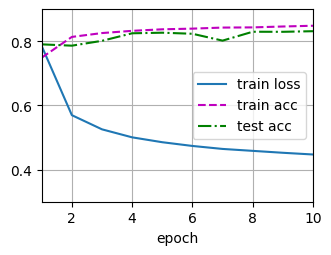

In [12]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

---

和以前一样，这个算法使结果收敛到一个相当高的精度，而且这次的代码比之前更精简了。

## 3.7.5.小结

* 使用深度学习框架的高级API，我们可以更简洁地实现softmax回归。
* 从计算的角度来看，实现softmax回归比较复杂。在许多情况下，深度学习框架在这些著名的技巧之外采取了额外的预防措施，来确保数值的稳定性。这使我们避免了在实践中从零开始编写模型时可能遇到的陷阱。

---



## 3.7.6.练习

1. 尝试调整超参数，例如批量大小、迭代周期数和学习率，并查看结果。
2. 增加迭代周期的数量。为什么测试精度会在一段时间后降低？我们怎么解决这个问题？


详细参考答案见 [answers/03.07_reference_answer](./answers/03.07_reference_answer.ipynb)。

#### 参考答案（PyPTO）

In [ ]:
!cat answers/txt/03.07_reference_answer_pypto.txt

#### 参考答案（PyTorch）

In [ ]:
!cat answers/txt/03.07_reference_answer_pytorch.txt